# BDI Prediction — Error Analysis
---
Compares predictions from all three models across the 505-patient BDI evaluation set.

**Inputs**: the three `*_predictions.csv` files saved by the eval notebooks  
**Goal**:
1. Side-by-side accuracy and confusion matrices per model
2. Identify where Gemma 4 diverges from the other two
3. Per-severity-class breakdown — which categories are hardest?
4. Sample inspection of systematic errors

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

SEVERITY_ORDER  = ['Minimal', 'Mild', 'Moderate', 'Severe']
SEVERITY_COLORS = {'Minimal': '#4393c3', 'Mild': '#92c5de',
                   'Moderate': '#f4a582', 'Severe': '#d6604d'}

## 1. Load predictions

Point `PRED_FILES` at your three results CSVs. The dict key becomes the model label throughout.

In [2]:
# ── Adjust these paths to wherever your results CSVs live ────────────────────
RESULTS_DIR = Path('../results')   # or wherever your eval notebooks write to

PRED_FILES = {
    'Gemma 3':    RESULTS_DIR / 'globem_gemma3_you_are_a_clinical_decision_support_assistant_specializing_in_be_20260410_020129_predictions.csv',       # adjust filename
    'MedGemma':   RESULTS_DIR / 'globem_medgemma15_you_are_a_clinical_decision_support_assistant_specializing_in_be_20260410_022735_predictions.csv',     # adjust filename
    'Gemma 4':    RESULTS_DIR / 'globem_gemma4_backbone_you_are_a_clinical_decision_support_assistant_specializing_in_be_20260410_024204_predictions.csv',  # adjust filename
}

dfs = {}
for label, path in PRED_FILES.items():
    df = pd.read_csv(path)
    df['model'] = label
    # Normalise: ensure prediction_text is a string, NaN → ''
    df['prediction_text'] = df['prediction_text'].fillna('').astype(str)
    df['gold_answer']     = df['gold_answer'].astype(str)
    df['correct']         = df['prediction_text'] == df['gold_answer']
    df['parse_fail']      = ~df['prediction_text'].isin(['Minimal','Mild','Moderate','Severe'])
    dfs[label] = df
    print(f"{label:12s}: {len(df):4d} rows | "
          f"acc={df['correct'].mean():.3f} | "
          f"parse_fail={df['parse_fail'].mean():.3f}")

Gemma 3     :  505 rows | acc=0.325 | parse_fail=0.000
MedGemma    :  505 rows | acc=0.457 | parse_fail=0.000
Gemma 4     :  505 rows | acc=0.158 | parse_fail=0.000


## 2. Top-level accuracy comparison

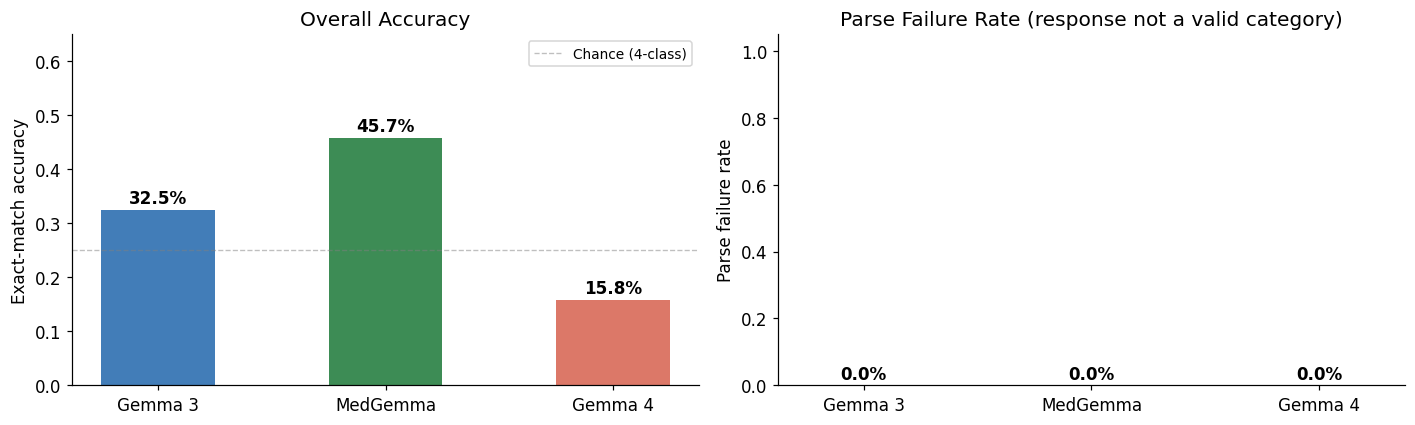

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── 2a. Accuracy bar ──────────────────────────────────────────────────────────
model_labels = list(dfs.keys())
accs = [dfs[m]['correct'].mean() for m in model_labels]
pfail = [dfs[m]['parse_fail'].mean() for m in model_labels]

colors = ['#2166ac', '#1b7837', '#d6604d']
bars = axes[0].bar(model_labels, accs, color=colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.1%}',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_ylim(0, 0.65)
axes[0].set_ylabel('Exact-match accuracy')
axes[0].set_title('Overall Accuracy')
axes[0].axhline(0.25, color='grey', linestyle='--', alpha=0.5, linewidth=0.9, label='Chance (4-class)')
axes[0].legend(fontsize=9)

# ── 2b. Parse failure rate ────────────────────────────────────────────────────
bars2 = axes[1].bar(model_labels, pfail, color=colors, alpha=0.85, width=0.5)
for bar, v in zip(bars2, pfail):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.1%}',
                 ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Parse failure rate')
axes[1].set_title('Parse Failure Rate (response not a valid category)')

plt.tight_layout()
plt.show()

## 3. Confusion matrices

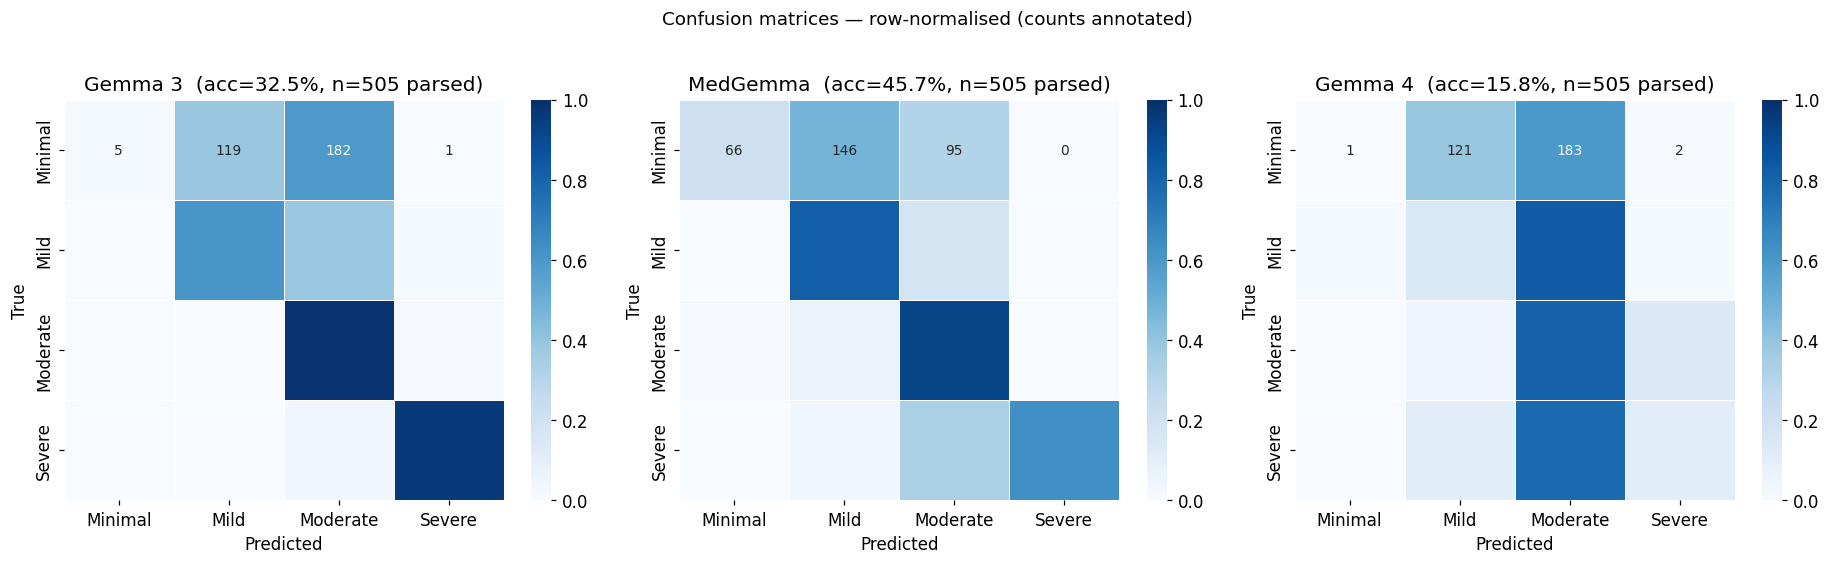

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (label, df) in zip(axes, dfs.items()):
    valid = df[~df['parse_fail']]
    cm = confusion_matrix(valid['gold_answer'], valid['prediction_text'],
                          labels=SEVERITY_ORDER)
    # Normalise by true class (row-wise)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER,
                linewidths=0.4, linecolor='white', vmin=0, vmax=1,
                annot_kws={'size': 9})
    ax.set_title(f'{label}  (acc={df["correct"].mean():.1%}, '
                 f'n={len(valid)} parsed)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion matrices — row-normalised (counts annotated)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 4. Per-class recall

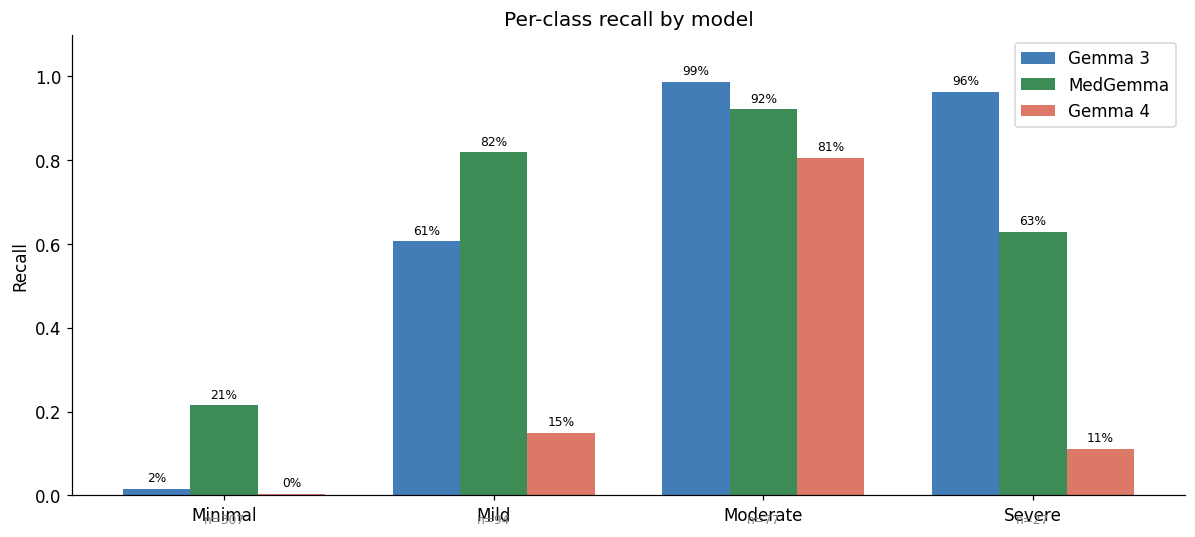

model     Gemma 3  Gemma 4  MedGemma
class                               
Minimal     0.016    0.003     0.215
Mild        0.606    0.149     0.819
Moderate    0.987    0.805     0.922
Severe      0.963    0.111     0.630


In [5]:
# Per-class recall for each model
recall_rows = []
for label, df in dfs.items():
    valid = df[~df['parse_fail']]
    for cls in SEVERITY_ORDER:
        subset = valid[valid['gold_answer'] == cls]
        recall = (subset['prediction_text'] == cls).mean() if len(subset) > 0 else np.nan
        recall_rows.append({'model': label, 'class': cls, 'recall': recall,
                             'support': len(subset)})

recall_df = pd.DataFrame(recall_rows)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(SEVERITY_ORDER))
w = 0.25
colors = ['#2166ac', '#1b7837', '#d6604d']

for i, (label, color) in enumerate(zip(dfs.keys(), colors)):
    sub = recall_df[recall_df['model'] == label].set_index('class').reindex(SEVERITY_ORDER)
    bars = ax.bar(x + (i - 1) * w, sub['recall'], width=w, label=label,
                  color=color, alpha=0.85)
    for bar, v in zip(bars, sub['recall']):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.0%}',
                    ha='center', va='bottom', fontsize=8)

# Annotate support
for j, cls in enumerate(SEVERITY_ORDER):
    sup = recall_df[recall_df['class'] == cls]['support'].iloc[0]
    ax.text(j, -0.06, f'n={sup}', ha='center', fontsize=8, color='grey',
            transform=ax.get_xaxis_transform())

ax.set_xticks(x)
ax.set_xticklabels(SEVERITY_ORDER)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class recall by model')
ax.legend()
plt.tight_layout()
plt.show()

print(recall_df.pivot(index='class', columns='model', values='recall')
               .reindex(SEVERITY_ORDER)
               .round(3).to_string())

## 5. Where does Gemma 4 diverge?

For each sample, check whether Gemma 3 and MedGemma agree but Gemma 4 disagrees.

In [6]:
# ── Merge all three on sample_id ─────────────────────────────────────────────
model_names = list(dfs.keys())
merged = dfs[model_names[0]][['sample_id','gold_answer','prediction_text','correct']].copy()
merged.columns = ['sample_id','gold_answer', f'pred_{model_names[0]}', f'correct_{model_names[0]}']

for m in model_names[1:]:
    sub = dfs[m][['sample_id','prediction_text','correct']].copy()
    sub.columns = ['sample_id', f'pred_{m}', f'correct_{m}']
    merged = merged.merge(sub, on='sample_id', how='inner')

print(f'Merged dataset: {len(merged)} samples')

# ── Cases where G3 and MedGemma agree but G4 differs ────────────────────────
g3_col  = f'pred_{model_names[0]}'
mg_col  = f'pred_{model_names[1]}'
g4_col  = f'pred_{model_names[2]}'

others_agree  = merged[g3_col] == merged[mg_col]
g4_disagrees  = merged[g4_col] != merged[g3_col]
g4_unique_err = merged[others_agree & g4_disagrees].copy()

print(f'\nSamples where Gemma 3 & MedGemma agree but Gemma 4 differs: {len(g4_unique_err)}')
print(f'  Of those, Gemma 4 is wrong and others are right: '
      f'{(g4_unique_err[f"correct_{model_names[0]}"] & ~g4_unique_err[f"correct_{model_names[2]}"]).sum()}')
print(f'  Of those, Gemma 4 is right and others are wrong: '
      f'{(~g4_unique_err[f"correct_{model_names[0]}"] & g4_unique_err[f"correct_{model_names[2]}"]).sum()}')

Merged dataset: 505 samples

Samples where Gemma 3 & MedGemma agree but Gemma 4 differs: 102
  Of those, Gemma 4 is wrong and others are right: 75
  Of those, Gemma 4 is right and others are wrong: 0


Samples correct by both Gemma 3 & MedGemma but wrong by Gemma 4: 75

True class (rows) vs Gemma 4 prediction (cols) on those samples:
pred_Gemma 4  Minimal  Mild  Moderate  Severe
gold_answer                                  
Minimal             0     3         1       0
Mild                1     0        42       0
Moderate            0     3         0      11
Severe              0     3        11       0


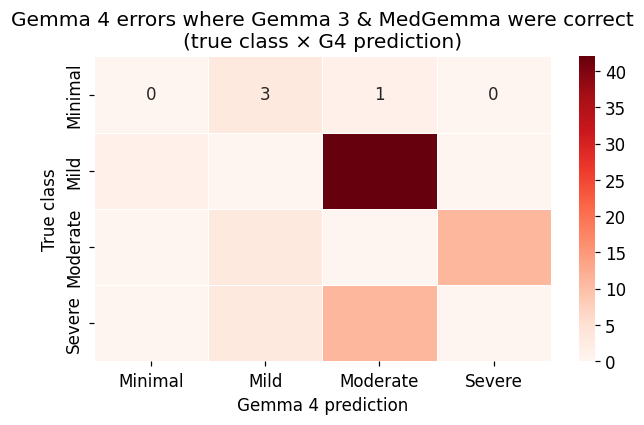

In [7]:
# ── What does Gemma 4 predict when the others agree correctly? ───────────────
others_correct = merged[f'correct_{model_names[0]}'] & merged[f'correct_{model_names[1]}']
g4_wrong       = ~merged[f'correct_{model_names[2]}']
g4_unique_miss = merged[others_correct & g4_wrong]

print(f'Samples correct by both Gemma 3 & MedGemma but wrong by Gemma 4: {len(g4_unique_miss)}')
print()

# What does Gemma 4 predict in those cases, broken down by true class?
cross = g4_unique_miss.groupby(['gold_answer', g4_col]).size().unstack(fill_value=0)
cross = cross.reindex(index=SEVERITY_ORDER, columns=SEVERITY_ORDER, fill_value=0)
print('True class (rows) vs Gemma 4 prediction (cols) on those samples:')
print(cross.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cross, annot=True, fmt='d', cmap='Reds', ax=ax,
            linewidths=0.4, linecolor='white')
ax.set_title("Gemma 4 errors where Gemma 3 & MedGemma were correct\n(true class × G4 prediction)")
ax.set_xlabel('Gemma 4 prediction')
ax.set_ylabel('True class')
plt.tight_layout()
plt.show()

## 6. Prediction distribution — is Gemma 4 biased toward certain categories?

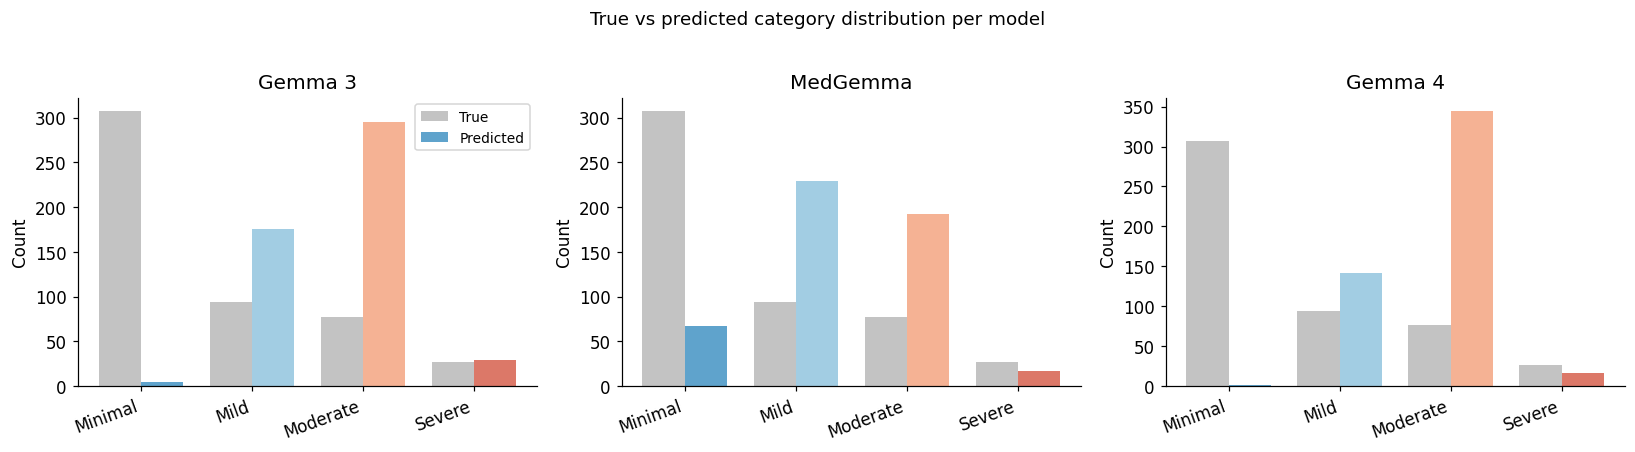

Prediction distribution (% of total):
           True  Gemma 3  MedGemma  Gemma 4
Minimal   0.608    0.010     0.133    0.004
Mild      0.186    0.349     0.453    0.281
Moderate  0.152    0.584     0.380    0.681
Severe    0.053    0.057     0.034    0.034


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
gold_dist = dfs[model_names[0]]['gold_answer'].value_counts().reindex(SEVERITY_ORDER).fillna(0)

for ax, (label, df) in zip(axes, dfs.items()):
    pred_dist = df['prediction_text'].value_counts().reindex(SEVERITY_ORDER).fillna(0)

    x = np.arange(len(SEVERITY_ORDER))
    w = 0.38
    b1 = ax.bar(x - w/2, gold_dist.values, width=w, label='True', color='#aaaaaa', alpha=0.7)
    b2 = ax.bar(x + w/2, pred_dist.values, width=w, label='Predicted',
                color=['#4393c3','#92c5de','#f4a582','#d6604d'], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(SEVERITY_ORDER, rotation=20, ha='right')
    ax.set_title(label)
    ax.set_ylabel('Count')
    if ax == axes[0]:
        ax.legend(fontsize=9)

plt.suptitle('True vs predicted category distribution per model', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# Numeric summary
print('Prediction distribution (% of total):')
dist_summary = pd.DataFrame({
    'True': gold_dist / gold_dist.sum(),
    **{label: df['prediction_text'].value_counts().reindex(SEVERITY_ORDER).fillna(0) / len(df)
       for label, df in dfs.items()}
}).reindex(SEVERITY_ORDER).round(3)
print(dist_summary.to_string())

## 7. Sample inspection — Gemma 4 systematic errors

Print a handful of cases where Gemma 4 is consistently wrong to spot any prompt or context patterns.

In [9]:
# ── Samples Gemma 4 always gets wrong (all 3 runs wrong would need re-runs, ──
# so here we just look at Gemma 4 wrong + at least one other right) ───────────
g4_wrong_others_right = merged[
    (~merged[f'correct_{model_names[2]}']) &
    (merged[f'correct_{model_names[0]}'] | merged[f'correct_{model_names[1]}'])
].copy()

print(f'Samples where Gemma 4 wrong but at least one other correct: {len(g4_wrong_others_right)}')
print()

# Show 10 examples, focusing on gold label and what each model said
sample_cols = ['sample_id', 'gold_answer', g3_col, mg_col, g4_col]
print(g4_wrong_others_right[sample_cols].head(10).to_string(index=False))

Samples where Gemma 4 wrong but at least one other correct: 168

         sample_id gold_answer pred_Gemma 3 pred_MedGemma pred_Gemma 4
INS-W_1003_2021_13     Minimal     Moderate       Minimal     Moderate
INS-W_1004_2021_13     Minimal     Moderate       Minimal         Mild
INS-W_1007_2021_13        Mild         Mild          Mild     Moderate
INS-W_1008_2021_13        Mild         Mild          Mild     Moderate
INS-W_1011_2021_13        Mild         Mild          Mild     Moderate
INS-W_1014_2021_13        Mild     Moderate          Mild     Moderate
INS-W_1016_2021_13        Mild     Moderate          Mild     Moderate
INS-W_1020_2021_13        Mild         Mild          Mild     Moderate
INS-W_1024_2021_13    Moderate     Moderate      Moderate       Severe
INS-W_1025_2021_13      Severe       Severe      Moderate     Moderate


In [10]:
# ── Error direction analysis: does Gemma 4 systematically over/underestimate? ─
sev_to_int = {'Minimal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}

for label, df in dfs.items():
    valid = df[~df['parse_fail'] & df['prediction_text'].isin(sev_to_int)].copy()
    valid['gold_int'] = valid['gold_answer'].map(sev_to_int)
    valid['pred_int'] = valid['prediction_text'].map(sev_to_int)
    valid['error']    = valid['pred_int'] - valid['gold_int']
    print(f"{label:12s}  mean error={valid['error'].mean():+.3f}  "
          f"(+ve = model predicts more severe than true)  "
          f"std={valid['error'].std():.3f}")

Gemma 3       mean error=+1.038  (+ve = model predicts more severe than true)  std=0.838
MedGemma      mean error=+0.663  (+ve = model predicts more severe than true)  std=0.825
Gemma 4       mean error=+1.093  (+ve = model predicts more severe than true)  std=0.889


## 8. Hypothesis: Gemma 4 system prompt issue

Gemma 4 does not support the `system` role in its chat template — when a system message is passed, it is silently dropped or malformed, so the model never sees the output format instruction. This section quantifies the impact by checking whether Gemma 4's parse failure rate is significantly higher than the other two.

In [11]:
print('Parse failure rates:')
for label, df in dfs.items():
    pf = df['parse_fail'].mean()
    n_fail = df['parse_fail'].sum()
    print(f'  {label:12s}: {pf:.1%}  ({n_fail}/{len(df)} samples)')

print()
print('If Gemma 4 parse failure >> others, the system prompt was not received.')
print('Fix: merge system_prompt_text into the first user message instead of')
print('using role="system", then re-run the eval notebook.')
print()
print('Suggested fix for the inference loop in eval_gemma4_backbone_globem.ipynb:')
print()
print('  messages = [')
print('      {"role": "user", "content": f"{system_prompt_text}\\n\\n{question}"},')
print('  ]')

Parse failure rates:
  Gemma 3     : 0.0%  (0/505 samples)
  MedGemma    : 0.0%  (0/505 samples)
  Gemma 4     : 0.0%  (0/505 samples)

If Gemma 4 parse failure >> others, the system prompt was not received.
Fix: merge system_prompt_text into the first user message instead of
using role="system", then re-run the eval notebook.

Suggested fix for the inference loop in eval_gemma4_backbone_globem.ipynb:

  messages = [
      {"role": "user", "content": f"{system_prompt_text}\n\n{question}"},
  ]


## 9. Summary table

In [ ]:
rows = []
for label, df in dfs.items():
    valid = df[~df['parse_fail']]
    row = {'Model': label, 'N': len(df),
           'Parse failures': f"{df['parse_fail'].mean():.1%}",
           'Accuracy (parsed)': f"{valid['correct'].mean():.1%}" if len(valid) else 'N/A',
           'Accuracy (all)': f"{df['correct'].mean():.1%}"}
    for cls in SEVERITY_ORDER:
        sub = valid[valid['gold_answer'] == cls]
        row[f'Recall {cls}'] = f"{(sub['prediction_text']==cls).mean():.1%}" if len(sub) > 0 else 'N/A'
    rows.append(row)

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))